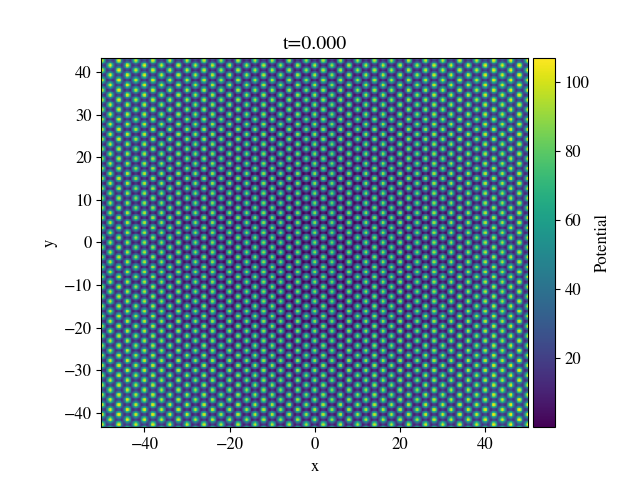

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from bloch_schrodinger.potential import create_parameter
from BECs.groundstate import GroundStateSSFM
from BECs.ssfm import SSFM
from BECs.potentialT import PotentialT

%matplotlib widget

res = 512
alpha = 0.5
g = 0.1
pop = 1
a = 2
amp = 20
omega = 1
lx, ly = a*50, a*3**0.5 / 2 * 50

lattice = PotentialT(
    [[lx, 0], [0, ly]],
    (res, res),
    v0 = 0
)

dirs = [np.cos(theta) * lattice.x + np.sin(theta) * lattice.y for theta in [0, 2*np.pi/3, 4*np.pi/3]]

for dir in dirs:
    lattice.add(value=np.cos( dir * 2 * np.pi / a) * amp + amp/2)

omega_lense = 1
T_lense = 2 * np.pi / omega_lense

lattice.square("lense_pulse", 0.12, T_lense * 0.25, 0.1, 0, 1)

lattice.add_shape("lense", omega_lense / 2 * (lattice.x**2+lattice.y**2))
lattice.add_term("lense * lense_pulse")


# lattice.rectangle(
#     center = (0,0),
#     dims = (lx-2*a, ly-a*3/2),
#     value = 60,
#     method = 'set',
#     inverse=True
# )

# lattice.smooth(2,2)

fig, ax = lattice.plot_t(0, 10)
plt.show()

In [2]:
grd = GroundStateSSFM(
    lattice.to_potential(t = 0),
    alpha,
    g
)
plt.close('all')
energy, psi0 = grd.solve(pop, tol_adapt = 1e-5, tol_stop = 1e-6)

Computing the ground states


  0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

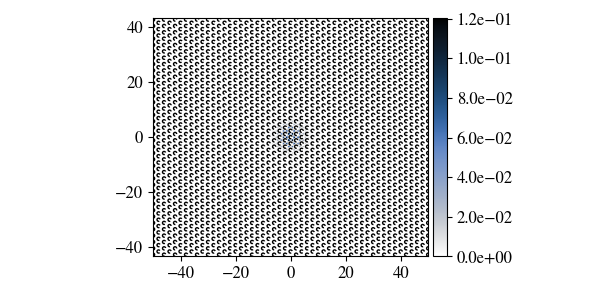

In [ ]:
from bloch_schrodinger.plotting import plot_eigenvector

plot_eigenvector(
    [[abs(psi0)**2]],
    [[lattice]],
    [['amplitude']]
)
plt.show()

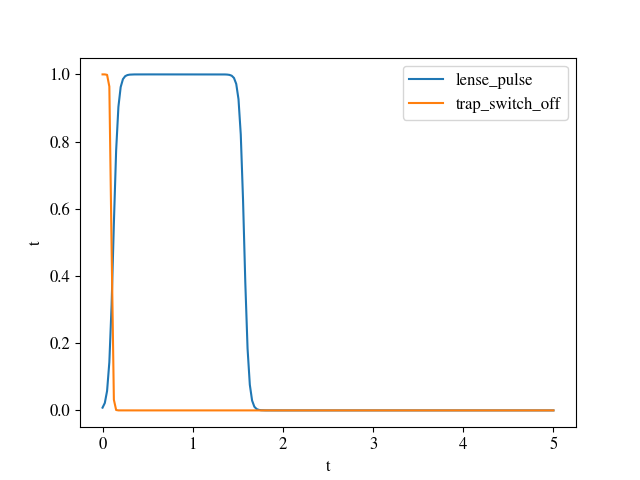

In [ ]:
%reload_ext autoreload
%autoreload 2


ti, tf = 0, 5
tof = 5
lattice.step("trap_switch_off", 0.1, 0.03, 1, 0)

lattice.plot_timefunction(["lense_pulse", "trap_switch_off"], ti, tf, 200)
plt.show()

In [ ]:

lattice.modulate("trap_switch_off")
# lattice.add_term("lense * lense_pulse2")


# lattice.plot_t(ti, tf, 200)
# plt.show()

In [ ]:
%reload_ext autoreload
%autoreload 2

t_sample = create_parameter('t', np.linspace(ti,tf, 200))
plt.close('all')

solv = SSFM(
    lattice,
    psi0,
    alpha,
    g
)
# print(lattice.timefuncs["lense_pulse"])
# print(lattice.create_timefunc("lense_pulse", {"omega_lense":3})(5))

psi = solv.solve(ti,tf,t_sample, tol = 1e-5, verbose=True)

Propagating the initial states. 1 iterations to perform


 99%|█████████▉| 4.959/5,  9.47s/it, [00:46 < 00:00]


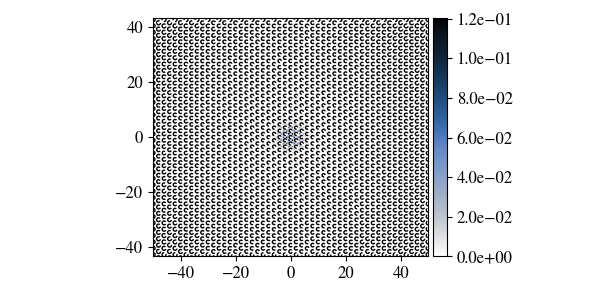

In [ ]:
%reload_ext autoreload
%autoreload 2

plt.close('all')
pot = lattice.to_potential(t_coord = t_sample)
plot_eigenvector(
    [[abs(psi)**2]],
    [[pot]],
    [['amplitude']]
)
plt.show()